# 🚲 Bike Sharing Demand — Bisiklet Kiralama Tahmini 🚲

Bu projede Washington D.C.'deki bir bisiklet paylaşım sistemine ait gerçek verilerle çalışıyoruz.
Amacımız; hava durumu, mevsim, saat gibi çevresel ve zamansal faktörleri kullanarak saatlik bisiklet kiralama sayısını (count) tahmin etmek. 

## Veri Sözlüğü

- datetime: Saatlik tarih ve zaman bilgisi  
- season: Mevsim (1: İlkbahar, 2: Yaz, 3: Sonbahar, 4: Kış)  
- holiday: Tatil günü olup olmadığı  
- workingday: İş günü olup olmadığı  
- weather: Hava durumu (1: Açık, 2: Sisli, 3: Yağışlı, 4: Şiddetli hava)  
- temp: Sıcaklık (°C)  
- atemp: Hissedilen sıcaklık (°C)  
- humidity: Nem oranı  
- windspeed: Rüzgar hızı  
- casual: Kayıtsız kullanıcı kiralamaları  
- registered: Kayıtlı kullanıcı kiralamaları  
- count: Toplam kiralama sayısı (Hedef Degişken)

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_log_error
import joblib
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
train = pd.read_csv('train.csv', parse_dates=['datetime'])
test  = pd.read_csv('test.csv',  parse_dates=['datetime'])

In [3]:
train.shape,test.shape

((10886, 12), (6493, 9))

## EDA – Exploratory Data Analysis

In [42]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  hour        10886 non-null  int32         
 13  dayofweek   10886 non-null  int32         
 14  month       10886 non-null  int32         
 15  year        10886 non-null  int32         
 16  day         10886 non-

In [43]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,dayofweek,month,year,day,is_weekend,is_rush,hour_cat
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,5,1,2011,1,1,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,5,1,2011,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,5,1,2011,1,1,0,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,5,1,2011,1,1,0,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,5,1,2011,1,1,0,0


In [44]:
train.shape

(10886, 20)

In [45]:
test.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
hour          0
dayofweek     0
month         0
year          0
day           0
is_weekend    0
is_rush       0
hour_cat      0
dtype: int64

In [46]:
train.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
hour          0
dayofweek     0
month         0
year          0
day           0
is_weekend    0
is_rush       0
hour_cat      0
dtype: int64

In [47]:
train.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,dayofweek,month,year,day,is_weekend,is_rush,hour_cat
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,11.541613,3.013963,6.521495,2011.501929,9.992559,0.290557,0.251056,1.381867
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,2011.000000,1.000000,0.000000,0.000000,0.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,6.000000,1.000000,4.000000,2011.000000,5.000000,0.000000,0.000000,0.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,12.000000,3.000000,7.000000,2012.000000,10.000000,0.000000,0.000000,1.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,18.000000,5.000000,10.000000,2012.000000,15.000000,1.000000,1.000000,2.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,23.000000,6.000000,12.000000,2012.000000,19.000000,1.000000,1.000000,3.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,6.915838,2.004585,3.444373,0.500019,5.476608,0.454040,0.433641,1.109842


<Axes: >

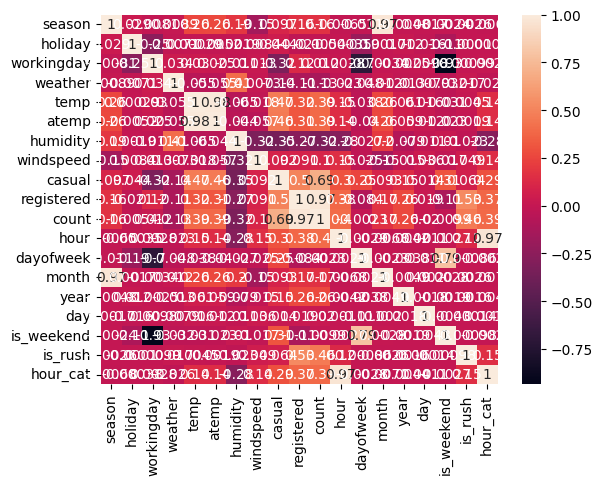

In [48]:
sns.heatmap(train.corr(numeric_only=True), annot=True)

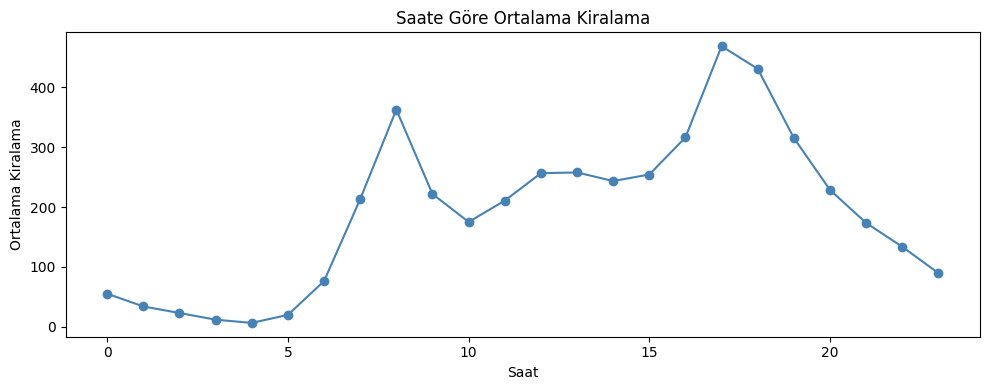

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
train.groupby(train['datetime'].dt.hour)['count'].mean().plot(ax=axes, color='steelblue', marker='o')
axes.set_title('Saate Göre Ortalama Kiralama')
axes.set_xlabel('Saat')
axes.set_ylabel('Ortalama Kiralama')

plt.tight_layout()
plt.show()

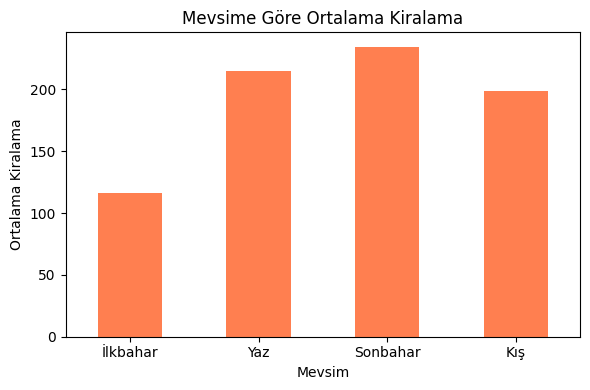

In [18]:
plt.figure(figsize=(6, 4))
train.groupby('season')['count'].mean().plot(kind='bar', color='coral')
plt.title('Mevsime Göre Ortalama Kiralama')
plt.xlabel('Mevsim')
plt.ylabel('Ortalama Kiralama')
plt.xticks(ticks=[0,1,2,3], labels=['İlkbahar','Yaz','Sonbahar','Kış'], rotation=0)
plt.tight_layout()
plt.show()

Mevsimlere göre kiralama sayısına baktığımızda Fall- Sonbaharda daha çok tercih edildiğini görüyoruz.

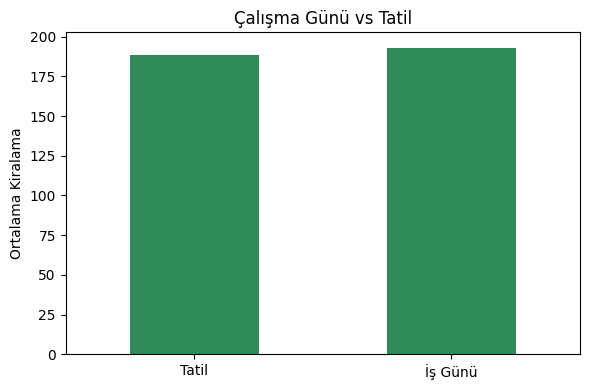

In [15]:
plt.figure(figsize=(6, 4))
train.groupby('workingday')['count'].mean().plot(kind='bar', color='seagreen')
plt.title('Çalışma Günü vs Tatil')
plt.xlabel('')
plt.ylabel('Ortalama Kiralama')
plt.xticks(ticks=[0,1], labels=['Tatil','İş Günü'], rotation=0)
plt.tight_layout()
plt.show()

Birde günlere göre ortalama bisiklet kiralama sayısı baktığımızda iş günleri en çok tercih edilenler arasında.

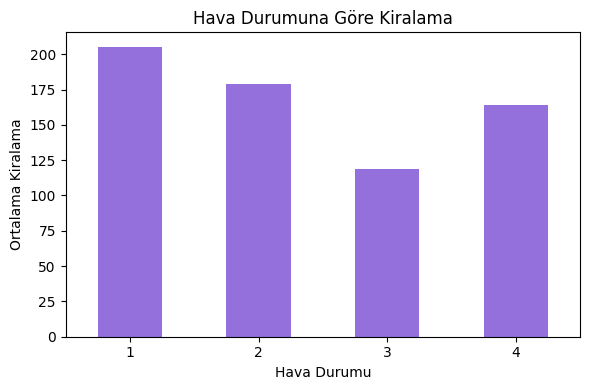

In [17]:
plt.figure(figsize=(6, 4))
train.groupby('weather')['count'].mean().plot(kind='bar', color='mediumpurple')
plt.title('Hava Durumuna Göre Kiralama')
plt.xlabel('Hava Durumu')
plt.ylabel('Ortalama Kiralama')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Hava durumuna göre ortalama kiralama sayısına baktığımızda açık günlerde daha çok tercih edildiğini görüyoruz.

## Feature Engineering

datetime sütunu tek başına projemiz için kullanışlı değil; bu yüzden saat, gün, ay ve yıl olarak parçalara ayırıyoruz. Bunun yanı sıra season ve weather sütunlarını da isimlendiriyoruz ki görselleştirme aşamasında daha rahat ve okunabilir görelim.

In [19]:
train['hour']       = train['datetime'].dt.hour
train['dayofweek']  = train['datetime'].dt.dayofweek
train['month']      = train['datetime'].dt.month
train['year']       = train['datetime'].dt.year
train['day']        = train['datetime'].dt.day
train['is_weekend'] = (train['dayofweek'] >= 5).astype(int)
train['is_rush']    = train['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
train['hour_cat']   = pd.cut(train['hour'], bins=[-1, 6, 12, 18, 24], labels=[0, 1, 2, 3]).astype(int)

In [20]:
test['hour']       = test['datetime'].dt.hour
test['dayofweek']  = test['datetime'].dt.dayofweek
test['month']      = test['datetime'].dt.month
test['year']       = test['datetime'].dt.year
test['day']        = test['datetime'].dt.day
test['is_weekend'] = (test['dayofweek'] >= 5).astype(int)
test['is_rush']    = test['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
test['hour_cat']   = pd.cut(test['hour'], bins=[-1, 6, 12, 18, 24], labels=[0, 1, 2, 3]).astype(int)

In [21]:
train[['hour', 'dayofweek', 'month', 'is_weekend', 'is_rush']].head()

,hour,dayofweek,month,is_weekend,is_rush
0,0,5,1,1,0
1,1,5,1,1,0
2,2,5,1,1,0
3,3,5,1,1,0
4,4,5,1,1,0


## Modelling and Testing

In [22]:
columns = ['season','holiday','workingday','weather','temp','atemp',
            'humidity','windspeed','hour','dayofweek','month','year',
            'day','is_weekend','is_rush','hour_cat']

X ve Y'yi belirliyoruz.

In [24]:
x = train[columns]
y = train['count']

In [26]:
x_tahmin = test[columns]

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Random Forest modelini oluşturuyoruz.Eğitelim, tahmin alalım ve R² skorumuzu öğrenelim.

In [28]:
rf= RandomForestRegressor()

In [29]:
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [30]:
y_pred = rf.predict(x_test)

Sonucumuza bakacak olursak modelimizin test verisini %95'ini doğru tahmin edebildiğini gösteriyor.

In [33]:
r2_score(y_test,y_pred)

0.9539198471361079

In [34]:
mean_squared_error(y_test,y_pred)**.5

38.999546795181715

Eğittiğimiz modeli kaydediyoruz.

In [35]:
joblib.dump(rf, 'random_forest_model.joblib')

['random_forest_model.joblib']

## Model Comparison

Şimdi de farklı modelleri karşılaştırarak verimize en uygun olanı seçelim.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()
        rf = RandomForestRegressor()

        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor,rf]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor','RandomForest']

        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [38]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.960058,36.309173,23.306337
RandomForest,0.954712,38.663001,24.120914
Decision Tree,0.909852,54.548304,33.170340
Extra Tree,0.896558,58.432120,35.511019
Gradient Boosting,0.881112,62.642788,43.085615
AdaBoost,0.852504,69.773754,48.682461
mlp_regressor,0.762417,88.554403,65.001493
KNeighborsRegressor,0.666741,104.880284,90.992162
SVR,0.594014,115.759833,76.671586
Linear,0.562113,120.221937,90.134455


Eğittiğimiz Random Forest modelini kullanarak Kaggle test verisini tahmin ediyoruz.

In [39]:
y_pred_kaggle = rf.predict(x_tahmin)
y_pred_kaggle = np.clip(y_pred_kaggle, 0, None)
y_pred_kaggle = y_pred_kaggle.round().astype(int)

Projemizi csv formatında kaydediyoruz.

In [40]:
submission = pd.DataFrame({
    'datetime': test['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S'),
    'count':    y_pred_kaggle
})

submission.to_csv('submission.csv', index=False)
print("submission.csv hazir!")
print(submission.head())

submission.csv hazir!
              datetime  count
0  2011-01-20 00:00:00     14
1  2011-01-20 01:00:00      8
2  2011-01-20 02:00:00      7
3  2011-01-20 03:00:00      4
4  2011-01-20 04:00:00      3


Bu projede Washington D.C.'deki bisiklet kiralama sisteminin saatlik talebini tahmin etmeye çalıştık. Veriye baktığımızda sabah ve akşam saatlerinde kiralamanın çok arttığını, hava kötü olduğunda ise insanların bisiklete binmediğini gördük. Tarih sütunundan saat, gün, ay gibi yeni özellikler çıkardık. Birkaç farklı model denedik ve en iyi sonucu XGBRegressor verdi. Sonuçları submission.csv olarak kaydettik.

Tesekkürler :)